### Traveling Salesman Problem (TSP)

The Traveling Salesman Problem is one of the most important problems in operations research, as well as in mathematics and computer science. Given a graph, the goal is to find the Hamiltonian tour, that is, the route of minimum total distance that visits every node exactly once and returns to the starting point.

Let $N$ be the set of cities, and let $c_{ij}$ denote the cost of traveling from city $i$ to city $j$. We define a binary decision variable $x_{ij}$ equal to 1 if the tour goes directly from city $i$ to city $j$, for $i \neq j$, and 0 otherwise. The MTZ (Miller-Tucker-Zemlin) formulation introduces an auxiliary variable $u_i$ in order to add subtour elimination constraints.

The formulation is as follows:

$$
\begin{aligned}
\min \quad & \sum_{i \in N} \sum_{\substack{j \in N \\ j \ne i}} c_{ij} x_{ij} \\
\text{s.t.} \quad
& \sum_{\substack{i \in N \\ i \ne j}} x_{ij} = 1 && \forall j \in N \\
& \sum_{\substack{j \in N \\ j \ne i}} x_{ij} = 1 && \forall i \in N \\
& u_i - u_j + |N| x_{ij} \leq |N| - 1 && \forall i \ne j,\; i,j \in N \setminus \{0\} \\
& x_{ij} \in \{0,1\} && \forall i,j \in N \\
& u_i \in \mathbb{R} && \forall i \in N
\end{aligned}
$$


In [1]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
import itertools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 57.0 MB/s eta 0:00:00


In [2]:
# Data
# Example with 5 cities
cities = {0: (0, 0), 1: (1, 5), 2: (2, 3), 3: (5, 2), 4: (6, 6)}

# Compute distance matrix
dist = {(i, j): round(((cities[i][0] - cities[j][0]) ** 2 +
                       (cities[i][1] - cities[j][1]) ** 2) ** 0.5)
        for i, j in itertools.permutations(cities, 2)}

In [3]:
# Create model
m = gp.Model("TSP")

# Routing variables
x = m.addVars(dist.keys(), vtype=GRB.BINARY, name="x")

# Auxiliary variables for subtour elimination
u = m.addVars(cities.keys(), vtype=GRB.CONTINUOUS, name="u")

m.setObjective(gp.quicksum(dist[i, j] * x[i, j] for i, j in dist), GRB.MINIMIZE)

# Each city must have exactly one outgoing and one incoming arc in the tour
for i in cities:
    m.addConstr(gp.quicksum(x[i, j] for j in cities if j != i) == 1)
    m.addConstr(gp.quicksum(x[j, i] for j in cities if j != i) == 1)

# MTZ subtour elimination constraints
for i in cities:
    for j in cities:
        if i != j and i != 0 and j != 0:
            m.addConstr(u[i] - u[j] + len(cities) * x[i, j] <= len(cities) - 1)

# Optimize
# m.write("TSP.lp")
m.optimize()

# Extract solution
solution = [(i, j) for i, j in x.keys() if x[i, j].X > 0.5]
print("Optimal tour:", solution)

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 22 rows, 25 columns and 76 nonzeros (Min)
Model fingerprint: 0x9d56aeba
Model has 20 linear objective coefficients
Variable types: 5 continuous, 20 integer (20 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [2e+00, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]

Found heuristic solution: objective 25.0000000
Presolve removed 0 rows and 1 columns
Presolve time: 0.00s
Presolved: 22 rows, 24 columns, 76 nonzeros
Variable types: 4 continuous, 20 integer (20 binary)

Root relaxation: objective 1.940000e+01, 12 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bo

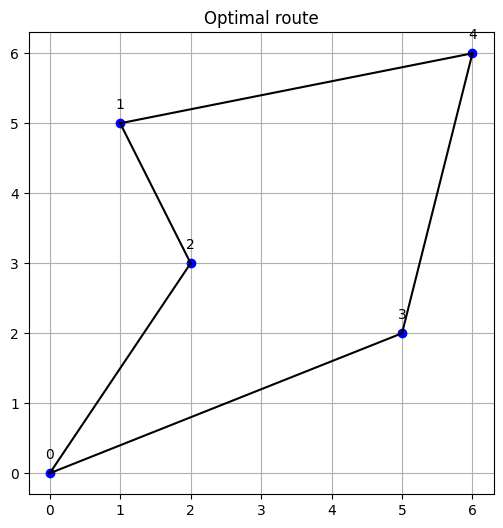

In [5]:
import matplotlib.pyplot as plt
import random

# Extract the optimal route
solution = [(i, j) for i, j in x.keys() if x[i, j].X > 0.5]
n = len(cities)

# Function to plot the route
def plot_route(route, title):
    plt.figure(figsize=(6, 6))
    for i in cities:
        plt.plot(*cities[i], 'bo')
        plt.text(cities[i][0], cities[i][1] + 0.2, f"{i}", ha='center')
    for i, j in route:
        plt.plot([cities[i][0], cities[j][0]], [cities[i][1], cities[j][1]], 'k-')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_route(solution, "Optimal route")

In [6]:
for j in cities:
    print(f"{j}:", u[j].x)

0: 0.0
1: 2.0
2: 3.0
3: 0.0
4: 1.0


In [7]:
# Seed for reproducibility
random.seed(42)

# Generate cities with random coordinates
cities = {i: (random.randint(0, 100), random.randint(0, 100)) for i in range(44)}
n = len(cities)

# Compute Euclidean distance matrix
dist = {
    (i, j): round(((cities[i][0] - cities[j][0]) ** 2 + (cities[i][1] - cities[j][1]) ** 2) ** 0.5)
    for i, j in itertools.permutations(cities, 2)
}

In [8]:
# Create model
m = gp.Model("TSP")

# Routing variables
x = m.addVars(dist.keys(), vtype=GRB.BINARY, name="x")

# Auxiliary variables for subtour elimination
u = m.addVars(cities.keys(), vtype=GRB.CONTINUOUS, name="u")

m.setObjective(gp.quicksum(dist[i, j] * x[i, j] for i, j in dist), GRB.MINIMIZE)

# Each city must have exactly one outgoing and one incoming arc in the tour
for i in cities:
    m.addConstr(gp.quicksum(x[i, j] for j in cities if j != i) == 1)
    m.addConstr(gp.quicksum(x[j, i] for j in cities if j != i) == 1)

# MTZ subtour elimination constraints
for i in cities:
    for j in cities:
        if i != j and i != 0 and j != 0:
            m.addConstr(u[i] - u[j] + len(cities) * x[i, j] <= len(cities) - 1)

# Optimize
# m.write("TSP.lp")
m.optimize()

# Extract solution
solution = [(i, j) for i, j in x.keys() if x[i, j].X > 0.5]
print("Optimal tour:", solution)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1894 rows, 1936 columns and 9202 nonzeros (Min)
Model fingerprint: 0x674ecafd
Model has 1892 linear objective coefficients
Variable types: 44 continuous, 1892 integer (1892 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [2e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01]

Presolve removed 0 rows and 1 columns
Presolve time: 0.02s
Presolved: 1894 rows, 1935 columns, 9202 nonzeros
Variable types: 43 continuous, 1892 integer (1892 binary)

Root relaxation: objective 4.548182e+02, 166 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node

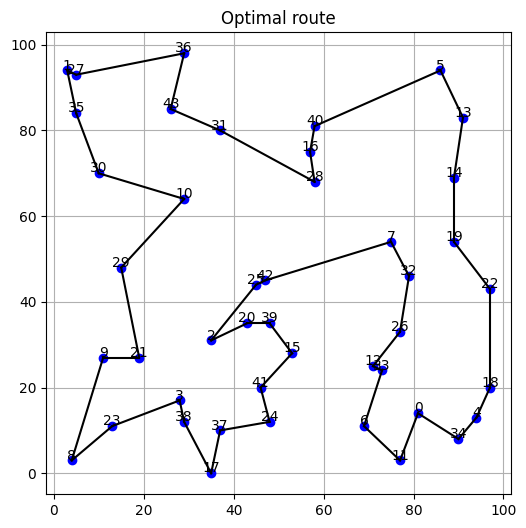

In [9]:
import matplotlib.pyplot as plt
import random

# Extract the optimal route
solution = [(i, j) for i, j in x.keys() if x[i, j].X > 0.5]
n = len(cities)

# Function to plot the route
def plot_route(route, title):
    plt.figure(figsize=(6, 6))
    for i in cities:
        plt.plot(*cities[i], 'bo')
        plt.text(cities[i][0], cities[i][1] + 0.2, f"{i}", ha='center')
    for i, j in route:
        plt.plot([cities[i][0], cities[j][0]], [cities[i][1], cities[j][1]], 'k-')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_route(solution, "Optimal route")